# Model Testing & Experimentation

This notebook explores different modeling approaches for the UBI Risk Scoring project. 
1. **Simple Baseline**: Tweedie GLM
2. **Advanced Baseline**: XGBoost Regressor
3. **Optimization**: Hyperparameter tuning using Optuna

In [3]:
import joblib
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_tweedie_deviance
from sklearn.base import BaseEstimator, RegressorMixin
import matplotlib.pyplot as plt

# Define Gini Coefficient Function for Evaluation
def gini_coefficient(actual, pred, weight):
    # Sort by predicted risk (ascending)
    idx = np.argsort(pred)
    actual_sorted = actual.iloc[idx]
    weight_sorted = weight.iloc[idx]

    # Cumulative sums
    cum_actual = np.cumsum(actual_sorted) / np.sum(actual_sorted)
    cum_weight = np.cumsum(weight_sorted) / np.sum(weight_sorted)

    # Gini is 2 * Area between Lorenz curve and 45-degree line
    gini = 1 - 2 * np.trapz(cum_actual, cum_weight)
    return gini

## 1. Load and Preprocess Data

In [4]:
# Load the processed data bundle
data = joblib.load("processed_step_2.pkl")
X_train, y_train, w_train = data['train']
X_test, y_test, w_test = data['test']
preprocessor = data['preprocessor']

print("Transforming features...")
# Apply transformations (StandardScaler, OneHotEncoder)
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
print(f"Data Ready. Training Shape: {X_train_transformed.shape}")

Transforming features...
Data Ready. Training Shape: (542410, 48)


## 2. Simple Regressor (Tweedie GLM)
We start with a Generalized Linear Model (GLM) using the Tweedie distribution ($p=1.5$). This serves as a simpler, interpretable baseline.

In [5]:
print("Training Tweedie GLM...")
# power=1.5 for Compound Poisson-Gamma (Tweedie)
# link='log' ensures positive predictions
glm = TweedieRegressor(power=1.5, link='log', max_iter=1000)
glm.fit(X_train_transformed, y_train, sample_weight=w_train)

# Evaluate
y_pred_glm = glm.predict(X_test_transformed)
gini_glm = gini_coefficient(y_test, y_pred_glm, w_test)
dev_glm = mean_tweedie_deviance(y_test, y_pred_glm, power=1.5, sample_weight=w_test)

print(f"GLM Tweedie Deviance: {dev_glm:.5f}")
print(f"GLM Gini Coefficient: {gini_glm:.5f}")
joblib.dump(glm, "glm_tweedie_model.joblib")

Training Tweedie GLM...
GLM Tweedie Deviance: 42.95527
GLM Gini Coefficient: 0.15005


['glm_tweedie_model.joblib']

## 3. XGBoost Baseline
Next, we train a gradient boosting model with standard parameters to see the lift over the GLM.

In [6]:
print("Training XGBoost Baseline...")
xgb_base = xgb.XGBRegressor(
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)

xgb_base.fit(
    X_train_transformed, y_train,
    sample_weight=w_train,
    eval_set=[(X_test_transformed, y_test)],
    sample_weight_eval_set=[w_test],
    verbose=0
)

y_pred_xgb = xgb_base.predict(X_test_transformed)
gini_xgb = gini_coefficient(y_test, y_pred_xgb, w_test)
dev_xgb = mean_tweedie_deviance(y_test, y_pred_xgb, power=1.5, sample_weight=w_test)

print(f"XGBoost Baseline Deviance: {dev_xgb:.5f}")
print(f"XGBoost Baseline Gini: {gini_xgb:.5f}")
joblib.dump(xgb_base, "untuned_xgb_tweedie_model.joblib")

Training XGBoost Baseline...
XGBoost Baseline Deviance: 42.86738
XGBoost Baseline Gini: 0.15842


['untuned_xgb_tweedie_model.joblib']

## 4. Hyperparameter Tuning with Optuna
We use Optuna to find the optimal set of hyperparameters that minimizes the Tweedie Deviance.

In [7]:
def objective(trial):
    params = {
        'objective': 'reg:tweedie',
        'tweedie_variance_power': 1.5,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 100),
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': 0
    }
    
    model = xgb.XGBRegressor(**params)
    
    model.fit(
        X_train_transformed, y_train,
        sample_weight=w_train,
        eval_set=[(X_test_transformed, y_test)],
        sample_weight_eval_set=[w_test],
        verbose=False
    )
    
    preds = model.predict(X_test_transformed)
    # Minimize Deviance
    deviance = mean_tweedie_deviance(y_test, preds, power=1.5, sample_weight=w_test)
    return deviance

print("Starting Optuna Study...")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20) # 20 trials for demonstration

print("Best params:", study.best_params)
print("Best Deviance:", study.best_value)

tuned_xgb = xgb.XGBRegressor(**study.best_params, objective='reg:tweedie', tweedie_variance_power=1.5, n_jobs=-1, random_state=42)
tuned_xgb.fit(
    X_train_transformed, y_train,
    sample_weight=w_train,
    eval_set=[(X_test_transformed, y_test)],
    sample_weight_eval_set=[w_test],
    verbose=False
)

joblib.dump(tuned_xgb, "tuned_xgb_tweedie_model.joblib")

Starting Optuna Study...
Best params: {'n_estimators': 222, 'max_depth': 3, 'learning_rate': 0.04289961797071985, 'subsample': 0.9683964602733871, 'colsample_bytree': 0.5257237503990062, 'min_child_weight': 36}
Best Deviance: 42.724082774575436


['tuned_xgb_tweedie_model.joblib']

## 5. Evaluate Best Model

In [8]:
# Retrain with best parameters
best_params = study.best_params
best_params['objective'] = 'reg:tweedie'
best_params['tweedie_variance_power'] = 1.5
best_params['random_state'] = 42
best_params['n_jobs'] = -1

print("Retraining with optimal parameters...")
best_model = xgb.XGBRegressor(**best_params)
best_model.fit(
    X_train_transformed, y_train,
    sample_weight=w_train,
    eval_set=[(X_test_transformed, y_test)],
    sample_weight_eval_set=[w_test],
    verbose=0
)
y_pred_opt = best_model.predict(X_test_transformed)
gini_opt = gini_coefficient(y_test, y_pred_opt, w_test)

print(f"Optimized XGBoost Gini: {gini_opt:.5f}")

# Comparison
results = pd.DataFrame({
    'Model': ['GLM', 'XGB Baseline', 'XGB Tuned'],
    'Gini': [gini_glm, gini_xgb, gini_opt]
})
print("\n--- Final Comparison ---")
print(results)

Retraining with optimal parameters...
Optimized XGBoost Gini: 0.16208

--- Final Comparison ---
          Model      Gini
0           GLM  0.150046
1  XGB Baseline  0.158425
2     XGB Tuned  0.162078


## 6. LightGBM & CatBoost Tuning
Optimizing alternative gradient boosting libraries for the ensemble.

In [9]:
def objective_lgb(trial):
    params = {
        'objective': 'tweedie',
        'tweedie_variance_power': 1.5,
        'metric': 'tweedie',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train_transformed, y_train,
        sample_weight=w_train,
        eval_set=[(X_test_transformed, y_test)],
        eval_sample_weight=[w_test],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    preds = model.predict(X_test_transformed)
    return mean_tweedie_deviance(y_test, preds, power=1.5, sample_weight=w_test)

def objective_cat(trial):
    params = {
        'loss_function': 'Tweedie:variance_power=1.5',
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_seed': 42,
        'allow_writing_files': False,
        'silent': True
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train_transformed, y_train, sample_weight=w_train, eval_set=(X_test_transformed, y_test), early_stopping_rounds=50, verbose=False)
    preds = model.predict(X_test_transformed)
    return mean_tweedie_deviance(y_test, preds, power=1.5, sample_weight=w_test)

print("Running LightGBM Study...")
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=10)

print("Running CatBoost Study...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=5)

Running LightGBM Study...


/Users/willtrevarthen/opt/anaconda3/envs/prem-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/willtrevarthen/opt/anaconda3/envs/prem-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/willtrevarthen/opt/anaconda3/envs/prem-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/willtrevarthen/opt/anaconda3/envs/prem-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/willtrevarthen/opt/anaconda3/envs/prem-env/lib/python3.10/site-packages/sklearn/u

Running CatBoost Study...


## 7. Ensemble Strategy
Combining XGBoost, LightGBM, and CatBoost.

Training Ensemble Components...


/Users/willtrevarthen/opt/anaconda3/envs/prem-env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Ensemble Gini: 0.16496


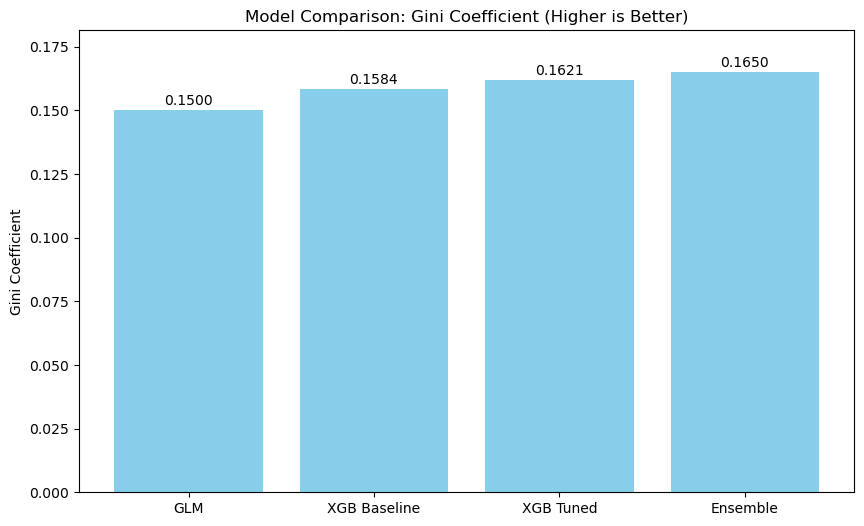

In [16]:
class TweedieEnsemble(BaseEstimator, RegressorMixin):
    def __init__(self, xgb_model, lgb_model, cat_model, weights=(0.34, 0.33, 0.33)):
        self.xgb_model = xgb_model
        self.lgb_model = lgb_model
        self.cat_model = cat_model
        self.weights = weights

    def predict(self, X):
        return (self.weights[0] * self.xgb_model.predict(X)) + \
               (self.weights[1] * self.lgb_model.predict(X)) + \
               (self.weights[2] * self.cat_model.predict(X))

# Train Best Models
print("Training Ensemble Components...")

# XGBoost
p_xgb = study.best_params
p_xgb.update({'objective': 'reg:tweedie', 'tweedie_variance_power': 1.5, 'n_jobs': -1, 'random_state': 42})
m_xgb = xgb.XGBRegressor(**p_xgb)
m_xgb.fit(X_train_transformed, y_train, sample_weight=w_train, verbose=0)

# LightGBM
p_lgb = study_lgb.best_params
p_lgb.update({'objective': 'tweedie', 'tweedie_variance_power': 1.5, 'n_jobs': -1, 'random_state': 42, 'verbosity': -1})
m_lgb = lgb.LGBMRegressor(**p_lgb)
m_lgb.fit(X_train_transformed, y_train, sample_weight=w_train)

# CatBoost
p_cat = study_cat.best_params
p_cat.update({'loss_function': 'Tweedie:variance_power=1.5', 'random_seed': 42, 'allow_writing_files': False, 'silent': True})
m_cat = CatBoostRegressor(**p_cat)
m_cat.fit(X_train_transformed, y_train, sample_weight=w_train)

# Evaluate Ensemble
ensemble = TweedieEnsemble(m_xgb, m_lgb, m_cat)
y_pred_ens = ensemble.predict(X_test_transformed)
gini_ens = gini_coefficient(y_test, y_pred_ens, w_test)
print(f"Ensemble Gini: {gini_ens:.5f}")
joblib.dump(ensemble, "tuned_tweedie_ensemble_model.joblib")

# Visualization
results = pd.DataFrame({
    'Model': ['GLM', 'XGB Baseline', 'XGB Tuned', 'Ensemble'],
    'Gini': [gini_glm, gini_xgb, gini_opt, gini_ens]
}).sort_values('Gini')

plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['Gini'], color='skyblue')
plt.title('Model Comparison: Gini Coefficient (Higher is Better)')
plt.ylabel('Gini Coefficient')
plt.ylim(0, max(results['Gini']) * 1.1)
for i, v in enumerate(results['Gini']):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center')
plt.show()